# EBay- Market Basket Analysis with Python

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

## Task 1: Data Cleaning and Preparation* Remove duplicate or inconsistent survey responses.
* Standardize categorical/numerical entries (e.g., frequency levels, gender, 
recommendation responses)
* Handle missing values and inconsistent formats in Product_Search_Method and other 
fields
* Rename duplicate or misformatted columns (e.g., remove trailing spaces in 
Rating_Accuracy )
* Convert numerical rating columns (e.g., Customer_Reviews_Importance, 
Shopping_Satisfaction) to appropriate numeric types for analysis.    lysis

In [2]:
# 1.1: Remove duplicate or inconsistent survey responses.

# Load Data
df = pd.read_csv("eBay.csv")
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:44:55 AM GMT+5:30,32,Prefer not to say,Multiple times a week,Groceries and Gourmet Food;Home and Kitchen,Sometimes,Rarely,categories,Multiple pages,5,...,Yes,Never,Yes,5,Yes,1,1,Customer service,.,819284
1,2023/06/07 9:28:09 AM GMT+5:30,47,Female,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,NaN,First page,5,...,Yes,Never,Sometimes,2,Yes,4,4,User-friendly website/app interface,Shipping speed and reliability,599249
2,2023/06/05 10:09:03 PM GMT+5:30,50,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Multiple times a day,categories,Multiple pages,1,...,Yes,Rarely,Sometimes,1,Sometimes,4,2,Customer service,Reducing packaging waste,432245
3,2023/06/07 5:58:12 PM GMT+5:30,6,Others,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,others,Multiple pages,1,...,No,Heavily,No,2,Yes,4,4,Product recommendations,Irrelevant product suggestions,476517
4,2023/06/07 11:46:52 AM GMT+5:30,61,Male,Once a week,Groceries and Gourmet Food;Clothing and Fashion,Yes,Rarely,NaN,Multiple pages,5,...,No,Never,Yes,2,No,3,2,Product recommendations,Shipping speed and reliability,894659


In [3]:
df.info()
print("Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   639 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  Add_to_Cart_Browsing                    800 non-null    object
 11  Cart_C

In [4]:
# Remove Duplicates
df = df.drop_duplicates()

In [5]:
# 1.2: Standardize categorical/numerical entries (e.g., frequency levels, gender, recommendation responses)

## Gender
df['Gender'] = df['Gender'].str.lower()

df["Gender"]=df["Gender"].replace({
    "m":"Male","male":"Male","f":"Female","female":"Female"})
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:44:55 AM GMT+5:30,32,prefer not to say,Multiple times a week,Groceries and Gourmet Food;Home and Kitchen,Sometimes,Rarely,categories,Multiple pages,5,...,Yes,Never,Yes,5,Yes,1,1,Customer service,.,819284
1,2023/06/07 9:28:09 AM GMT+5:30,47,Female,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,NaN,First page,5,...,Yes,Never,Sometimes,2,Yes,4,4,User-friendly website/app interface,Shipping speed and reliability,599249
2,2023/06/05 10:09:03 PM GMT+5:30,50,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Multiple times a day,categories,Multiple pages,1,...,Yes,Rarely,Sometimes,1,Sometimes,4,2,Customer service,Reducing packaging waste,432245
3,2023/06/07 5:58:12 PM GMT+5:30,6,others,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,others,Multiple pages,1,...,No,Heavily,No,2,Yes,4,4,Product recommendations,Irrelevant product suggestions,476517
4,2023/06/07 11:46:52 AM GMT+5:30,61,Male,Once a week,Groceries and Gourmet Food;Clothing and Fashion,Yes,Rarely,NaN,Multiple pages,5,...,No,Never,Yes,2,No,3,2,Product recommendations,Shipping speed and reliability,894659


In [6]:
# Purchase Frequency

df["Purchase_Frequency"]=df["Purchase_Frequency"].str.capitalize()
df.head()

# Recommendation Response

df["Recommendation_Helpfulness"] =df["Recommendation_Helpfulness"].str.capitalize()

In [7]:
# 1.3: Handle missing values and inconsistent formats in Product_Search_Method and other fields
df.isnull().sum()

Timestamp                                   0
age                                         0
Gender                                      0
Purchase_Frequency                          0
Purchase_Categories                         0
Personalized_Recommendation_Frequency       0
Browsing_Frequency                          0
Product_Search_Method                     161
Search_Result_Exploration                   0
Customer_Reviews_Importance                 0
Add_to_Cart_Browsing                        0
Cart_Completion_Frequency                   0
Cart_Abandonment_Factors                    0
Saveforlater_Frequency                      0
Review_Left                                 0
Review_Reliability                          0
Review_Helpfulness                          0
Personalized_Recommendation_Frequency       0
Recommendation_Helpfulness                  0
Rating_Accuracy                             0
Shopping_Satisfaction                       0
Service_Appreciation              

In [8]:
cat_col=["Gender","Product_Search_Method" ] 
for col in cat_col:    
    df[col].fillna(df[col].mode()[0],inplace=True) 
    
df['Product_Search_Method'].isnull().sum()

0

In [9]:
# 1.4: Rename duplicate or misformatted columns (e.g., remove trailing spaces in Rating_Accuracy ). 
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency', 'Recommendation_Helpfulness',
       'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction'],
      dtype='object')

In [10]:
# 1.5: Convert numerical rating columns (e.g., Customer_Reviews_Importance, Shopping_Satisfaction) to appropriate numeric types for analysis. 

num_col= ["Customer_Reviews_Importance","Shopping_Satisfaction","Rating_Accuracy"]

for col in num_col:
    df[col]=pd.to_numeric(df[col],errors="coerce")
    df[col].fillna(df[col].mean(),inplace=True)
df.head()


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:44:55 AM GMT+5:30,32,prefer not to say,Multiple times a week,Groceries and Gourmet Food;Home and Kitchen,Sometimes,Rarely,categories,Multiple pages,5,...,Yes,Never,Yes,5,Yes,1,1,Customer service,.,819284
1,2023/06/07 9:28:09 AM GMT+5:30,47,Female,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Keyword,First page,5,...,Yes,Never,Sometimes,2,Yes,4,4,User-friendly website/app interface,Shipping speed and reliability,599249
2,2023/06/05 10:09:03 PM GMT+5:30,50,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Multiple times a day,categories,Multiple pages,1,...,Yes,Rarely,Sometimes,1,Sometimes,4,2,Customer service,Reducing packaging waste,432245
3,2023/06/07 5:58:12 PM GMT+5:30,6,others,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,others,Multiple pages,1,...,No,Heavily,No,2,Yes,4,4,Product recommendations,Irrelevant product suggestions,476517
4,2023/06/07 11:46:52 AM GMT+5:30,61,Male,Once a week,Groceries and Gourmet Food;Clothing and Fashion,Yes,Rarely,Keyword,Multiple pages,5,...,No,Never,Yes,2,No,3,2,Product recommendations,Shipping speed and reliability,894659


## Task 2: Descriptive Behavior Analysis* Summarize customer demographics (age, gender distribution).
* Analyze overall purchase frequency and most popular product categories.
* Identify top browsing methods and most common cart abandonment factors.
* Calculate mean and median satisfaction, recommendation helpfulness, and rating 
accuracy
* Generate summary statistics and visualizations for key behavioral variables.. bles.

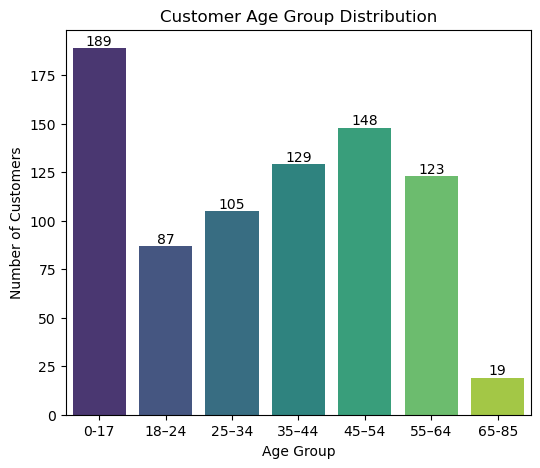

In [11]:
# 2.1: Summarize customer demographics (age, gender distribution).

age_bins = [0, 18, 25, 35, 45, 55, 65, 85]
age_labels = ["0-17","18–24", "25–34", "35–44", "45–54", "55–64", "65-85"]


df["Age_Group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels)
plt.figure(figsize=(6,5))
ax= sns.countplot(data=df, x="Age_Group", palette="viridis")

# Add value labels
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10)
    
plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.show()

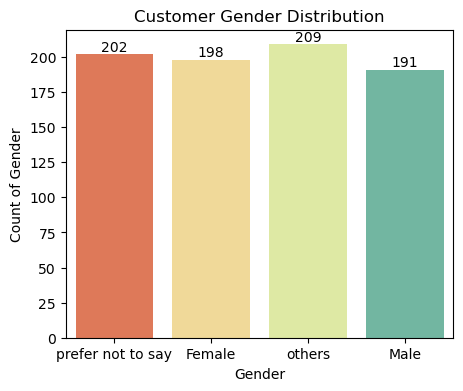

In [12]:
df["Gender"].value_counts()

plt.figure(figsize=(5,4))
ax = sns.countplot(data=df, x="Gender", palette="Spectral")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10)
plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count of Gender")
plt.show()

In [13]:
# 2.2: Analyze overall purchase frequency and most popular product categories

df["Purchase_Frequency"].value_counts()

Purchase_Frequency
Few times a month         172
Less than once a month    172
Once a month              160
Multiple times a week     148
Once a week               148
Name: count, dtype: int64

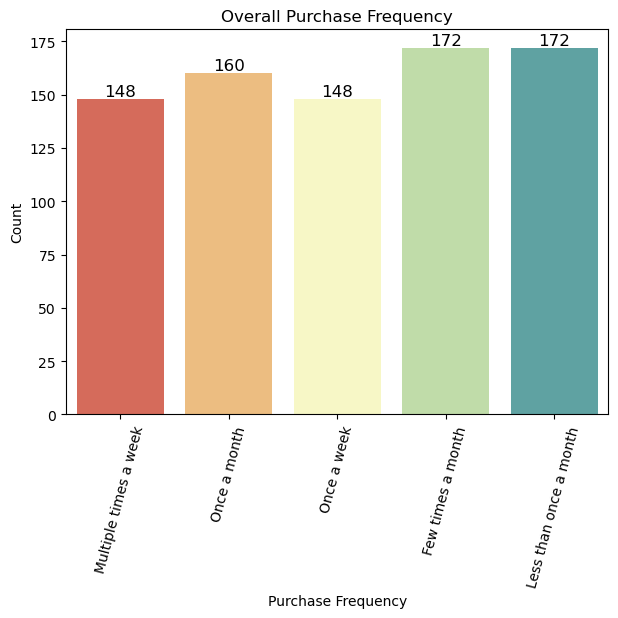

In [14]:
plt.figure(figsize=(7,5))

ax = sns.countplot(data=df, x="Purchase_Frequency", palette="Spectral")

plt.xticks(rotation=75) 
plt.xlabel("Purchase Frequency") 
plt.ylabel("Count") 
plt.title("Overall Purchase Frequency")

# Data Labels
for p in ax.patches:    
    ax.annotate(f'{int(p.get_height())}',(p.get_x() + p.get_width() / 2., p.get_height()),        
                ha='center',        
                va='bottom',        
                fontsize=12,        
                color='Black')
plt.show()

In [15]:
# Most Popular Product Categories
top_10_categories= df["Purchase_Categories"].value_counts().head(10)
print(f"Top 10 Product Categories:\n{top_10_categories}")

Top 10 Product Categories:
Purchase_Categories
Clothing and Fashion;others                                                                  40
Clothing and Fashion;Home and Kitchen;others                                                 36
Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion;Home and Kitchen    35
Groceries and Gourmet Food;Home and Kitchen                                                  34
Groceries and Gourmet Food;Clothing and Fashion;Home and Kitchen                             33
Groceries and Gourmet Food;Beauty and Personal Care                                          33
Beauty and Personal Care;Clothing and Fashion;Home and Kitchen                               33
Beauty and Personal Care;Clothing and Fashion;Home and Kitchen;others                        31
others                                                                                       30
Groceries and Gourmet Food;Beauty and Personal Care;others                               

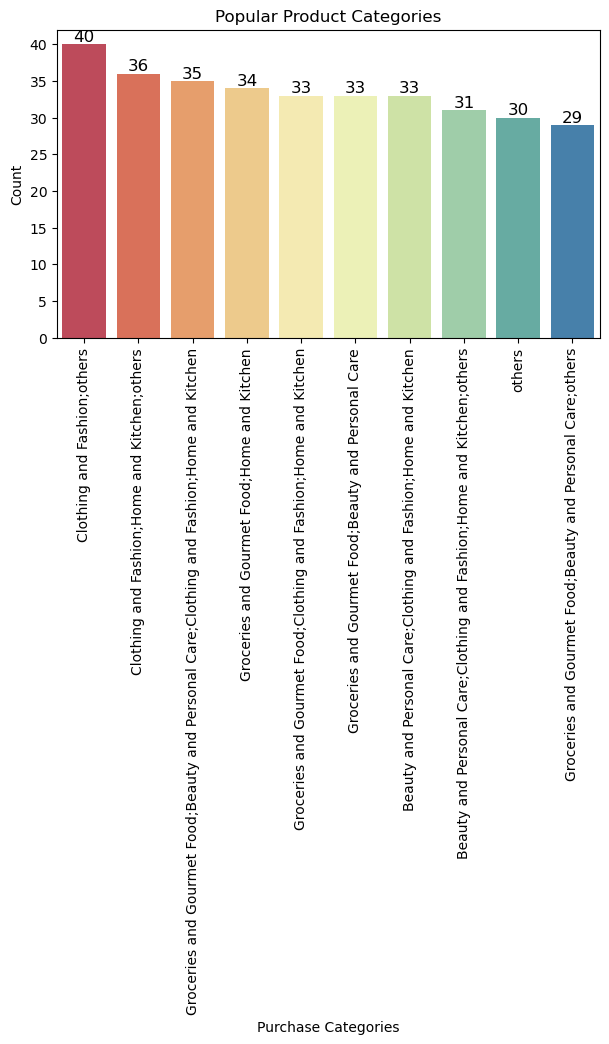

In [16]:
# Barplot for Popular Product Categories
plt.figure(figsize=(7,4))

counts = df['Purchase_Categories'].value_counts().head(10)
ax = sns.barplot(x=counts.index, y=counts.values, palette='Spectral')

plt.xticks(rotation=90) 
plt.xlabel("Purchase Categories") 
plt.ylabel("Count") 
plt.title("Popular Product Categories")

# Data Labels
for i, v in enumerate(counts.values): 
    ax.text( i, v, str(v), ha='center', va='bottom', fontsize=12 )
plt.show()

In [17]:
# 2.3: Identify top browsing methods and most common cart abandonment factors.

# a) Top Browsing Methods
top_browsing= df["Product_Search_Method"].value_counts().head()
print(f"Top Browsing Methods:\n{top_browsing}")

Top Browsing Methods:
Product_Search_Method
Keyword       336
others        164
categories    158
Filter        142
Name: count, dtype: int64


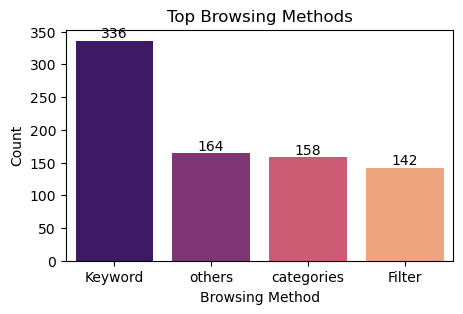

In [18]:
plt.figure(figsize=(5,3)) 

ax = sns.barplot(x=top_browsing.index,y=top_browsing.values,palette='magma') 
plt.title("Top Browsing Methods") 
plt.xlabel("Browsing Method") 
plt.ylabel("Count") 

# Data labels 
for i, v in enumerate(top_browsing.values):
    ax.text(i, v, str(v), ha='center', va='bottom') 
plt.show()

In [19]:
# b) Most common cart abandonment factors

Cart_Abandonment_Factors = df['Cart_Abandonment_Factors'].value_counts() 
print("Cart_Abandonment_Factors_Method:") 
print(Cart_Abandonment_Factors)

Cart_Abandonment_Factors_Method:
Cart_Abandonment_Factors
High shipping costs                           208
others                                        204
Changed my mind or no longer need the item    204
Found a better price elsewhere                184
Name: count, dtype: int64


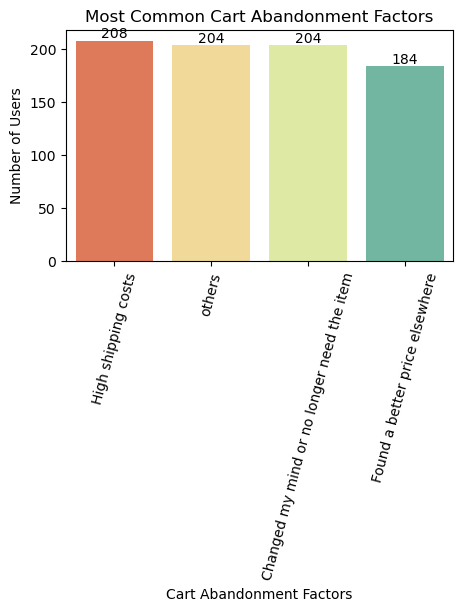

In [20]:
plt.figure(figsize=(5,3)) 

ax= sns.barplot(x= Cart_Abandonment_Factors.index,
                y= Cart_Abandonment_Factors.values,    
                palette='Spectral')

plt.title("Most Common Cart Abandonment Factors") 
plt.xlabel("Cart Abandonment Factors") 
plt.ylabel("Number of Users") 
plt.xticks(rotation=75)

#  Data labels: 
for p in ax.patches:    
    ax.annotate(f'{int(p.get_height())}',        
                (p.get_x() + p.get_width()/2., p.get_height()),        
                ha='center',        
                va='bottom',        
                fontsize=10) 
plt.tight_layout() 
plt.show()

In [21]:
# 2.4: Calculate mean and median satisfaction, recommendation helpfulness, and rating accuracy.

## Mean: 
df[['Shopping_Satisfaction','Rating_Accuracy']].mean()

## Median:
df[['Shopping_Satisfaction','Rating_Accuracy']].median()


Shopping_Satisfaction    3.0
Rating_Accuracy          3.0
dtype: float64

In [22]:
df["Recommendation_Helpfulness"].unique()

# Encode to numeric values
df["Recommendation_Helpfulness_Num"] = (df["Recommendation_Helpfulness"]
    .str.strip()
    .str.lower().map({"no": 0,"sometimes": 1,"yes": 2}))

metrics = ["Recommendation_Helpfulness_Num"]

mean_median_stats = df[metrics].agg(["mean", "median"])
print(mean_median_stats)



        Recommendation_Helpfulness_Num
mean                           0.98625
median                         1.00000


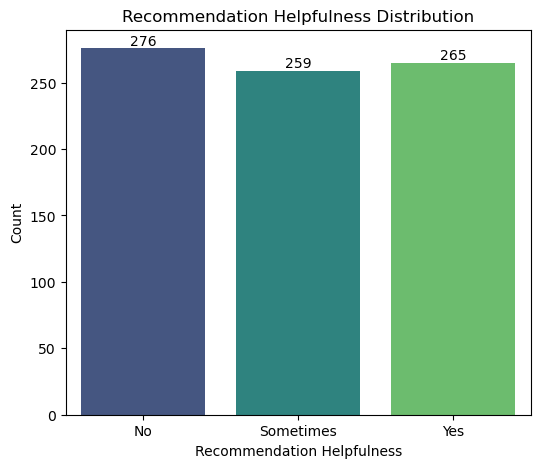

In [23]:
# 2.5: Generate summary statistics and visualizations for key behavioral variables. 

## Recommendation Helpfulness Distribution:

plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="Recommendation_Helpfulness",
    order=["No", "Sometimes", "Yes"],
    palette="viridis")

plt.xlabel("Recommendation Helpfulness")
plt.ylabel("Count")
plt.title("Recommendation Helpfulness Distribution")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10)

plt.show()


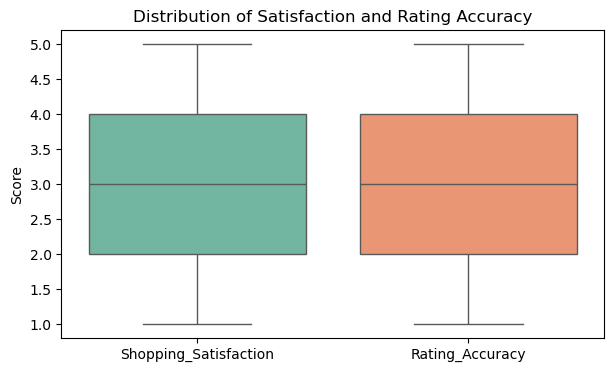

In [24]:
## Shopping Satisfaction & Rating Accuracy (Distribution): 
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df[["Shopping_Satisfaction", "Rating_Accuracy"]],
    palette="Set2")

plt.title("Distribution of Satisfaction and Rating Accuracy")
plt.ylabel("Score")
plt.show()


## Task 3: Customer Segmentation and Profiling * Segment customers based on purchase frequency and shopping satisfaction levels.
* Create profiles such as:
  - Frequent Buyers: High purchase frequency, high satisfaction.
  - Occasional Shoppers: Medium frequency, moderate satisfaction.
  - At-Risk Customers: Low satisfaction or frequent cart abandonment.
* Analyze demographic or behavioral differences across these segments.
* Use clustering (e.g., K-Means) for behavioral grouping based on survey responses.eonses. 

In [25]:
df["Shopping_Satisfaction"].value_counts()

Shopping_Satisfaction
1    191
2    160
3    158
4    147
5    144
Name: count, dtype: int64

In [26]:
# 3.1: Segment customers based on purchase frequency and shopping satisfaction levels.

frequency_map = {
    "Less than once a month": "Low",
    "Once a month": "Medium",
    "Few times a month": "Medium",
    "Once a week": "High",
    "Multiple times a week": "High"}

df["Purchase_Frequency_Level"] = df["Purchase_Frequency"].map(frequency_map)

In [27]:
# 3.2 Create profiles such as: 
## a) Frequent Buyers: High purchase frequency, high satisfaction. 
## b) Occasional Shoppers: Medium frequency, moderate satisfaction. 
## c) At-Risk Customers: Low satisfaction or frequent cart abandonment.

def customer_seg(row):
    if row["Purchase_Frequency_Level"]== "High" and row["Shopping_Satisfaction"] >= 4:
        return "Frequent Buyers"
    elif row["Purchase_Frequency_Level"]== "Medium" and row["Shopping_Satisfaction"] == 3:
        return "Occasional Shoppers"
    else:
        return "At-Risk Customers"
        
df["Customer_Segment"]=df.apply(customer_seg,axis=1)

In [28]:
df["Customer_Segment"].value_counts()

Customer_Segment
At-Risk Customers      623
Frequent Buyers        109
Occasional Shoppers     68
Name: count, dtype: int64

In [29]:
df["Customer_Segment"]

0        At-Risk Customers
1          Frequent Buyers
2        At-Risk Customers
3        At-Risk Customers
4        At-Risk Customers
              ...         
795    Occasional Shoppers
796      At-Risk Customers
797      At-Risk Customers
798      At-Risk Customers
799      At-Risk Customers
Name: Customer_Segment, Length: 800, dtype: object

In [30]:
# 3.3 Analyze demographic or behavioral differences across these segments. 

## Age Distribution by Segment:
segment_age = df.groupby("Customer_Segment")["age"].agg(
    ["mean", "median", "min", "max", "count"]) 
print(segment_age)


                          mean  median  min  max  count
Customer_Segment                                       
At-Risk Customers    36.266453    38.0    3   67    623
Frequent Buyers      33.394495    33.0    3   67    109
Occasional Shoppers  34.558824    36.0    5   66     68


In [31]:
## Gender Distribution by Segment:
gender_segment = pd.crosstab(df["Customer_Segment"], df["Gender"])
print(gender_segment)


Gender               Female  Male  others  prefer not to say
Customer_Segment                                            
At-Risk Customers       152   147     172                152
Frequent Buyers          33    25      27                 24
Occasional Shoppers      13    19      10                 26


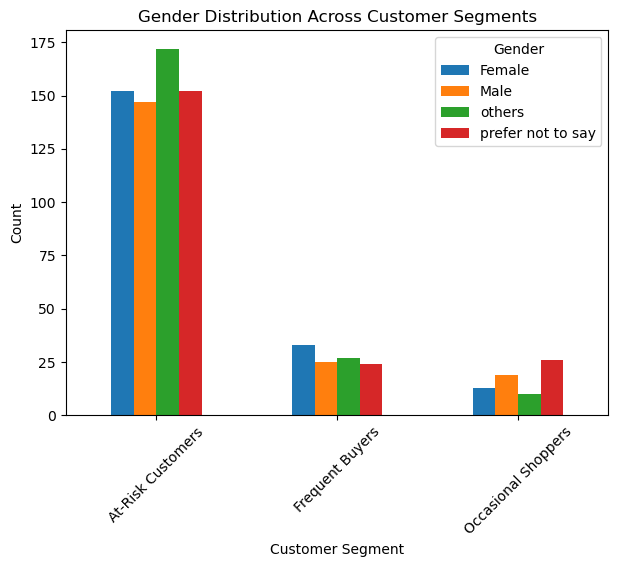

In [32]:
gender_segment.plot(kind="bar", figsize=(7,5))
plt.title("Gender Distribution Across Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Insight: Gender participation varies across segments, with balanced representation among frequent buyers.

In [33]:
## Shopping Satisfaction by Segment:
segment_satisfaction = df.groupby("Customer_Segment")["Shopping_Satisfaction"].mean()
print(segment_satisfaction)


Customer_Segment
At-Risk Customers      2.569823
Frequent Buyers        4.477064
Occasional Shoppers    3.000000
Name: Shopping_Satisfaction, dtype: float64


In [34]:
## Cart Abandonment Behaviour:
df.groupby('Customer_Segment')['Cart_Abandonment_Factors'].value_counts()

Customer_Segment     Cart_Abandonment_Factors                  
At-Risk Customers    others                                        170
                     High shipping costs                           161
                     Changed my mind or no longer need the item    159
                     Found a better price elsewhere                133
Frequent Buyers      Changed my mind or no longer need the item     29
                     Found a better price elsewhere                 29
                     others                                         26
                     High shipping costs                            25
Occasional Shoppers  Found a better price elsewhere                 22
                     High shipping costs                            22
                     Changed my mind or no longer need the item     16
                     others                                          8
Name: count, dtype: int64

In [35]:
# 3.4: Use clustering (e.g., K-Means) for behavioral grouping based on survey responses.
# import libraries : 
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans

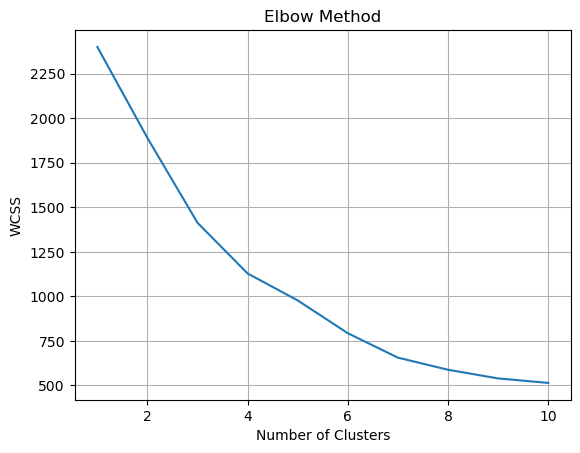

In [145]:
## K-Means Clustering 
Scatter_features= ['Shopping_Satisfaction','Customer_Reviews_Importance','Rating_Accuracy']

# Scale Data: 
X=df[Scatter_features]

scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid()
plt.show()

In [60]:
X.head()

,Shopping_Satisfaction,Customer_Reviews_Importance,Rating_Accuracy
0,1,5,1
1,4,5,4
2,2,1,4
3,4,1,4
4,2,5,3


In [39]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) 
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [40]:
df['Cluster'].value_counts()

Cluster
2    299
1    254
0    247
Name: count, dtype: int64

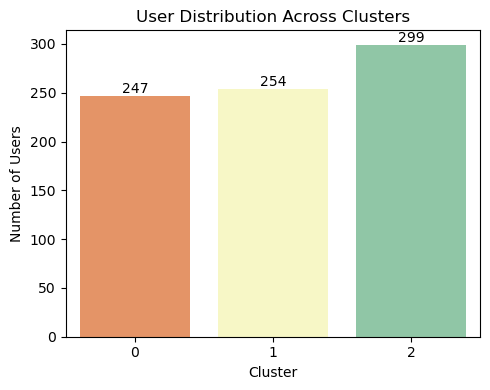

In [43]:
plt.figure(figsize=(5,4)) 
ax = sns.countplot(x='Cluster', data=df, palette='Spectral') 
plt.title("User Distribution Across Clusters") 
plt.xlabel("Cluster") 
plt.ylabel("Number of Users") 

# Data labels 
for p in ax.patches:    
    ax.annotate(int(p.get_height()),(p.get_x() + p.get_width() / 2., p.get_height()),
    ha='center', va='bottom')
plt.tight_layout() 
plt.show()

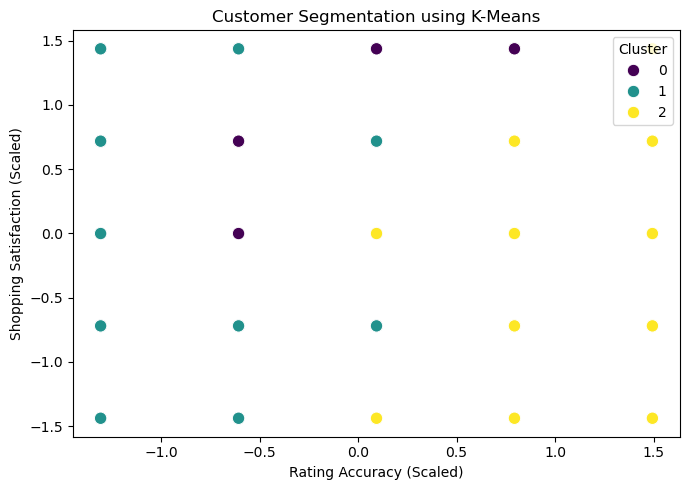

In [63]:
plt.figure(figsize=(7,5)) 

sns.scatterplot( x=X_scaled[:, 0], y=X_scaled[:, 1], 
                hue=df["Cluster"], palette="viridis", s=80) 
plt.title("Customer Segmentation using K-Means") 
plt.xlabel("Rating Accuracy (Scaled)") 
plt.ylabel("Shopping Satisfaction (Scaled)") 
plt.legend(title="Cluster") 
plt.tight_layout() 
plt.show()

## Task 4: Recommendation and Review Insights
* Examine the relationship between recommendation helpfulness and shopping 
satisfaction
* Evaluate how review reliability and helpfulness impact overall ratings.
* Identify trends in how often customers engage with or trust personalized 
recommendations
* Suggest actionable insights for improving eBay’s recommendation system. . 

In [146]:
# 4.1: Examine the relationship between recommendation helpfulness and shopping satisfaction.

correlation=df[['Shopping_Satisfaction', 'Customer_Reviews_Importance', 'Rating_Accuracy']].corr()
correlation

,Shopping_Satisfaction,Customer_Reviews_Importance,Rating_Accuracy
Shopping_Satisfaction,1.000000,0.012039,-0.039912
Customer_Reviews_Importance,0.012039,1.000000,-0.037404
Rating_Accuracy,-0.039912,-0.037404,1.000000


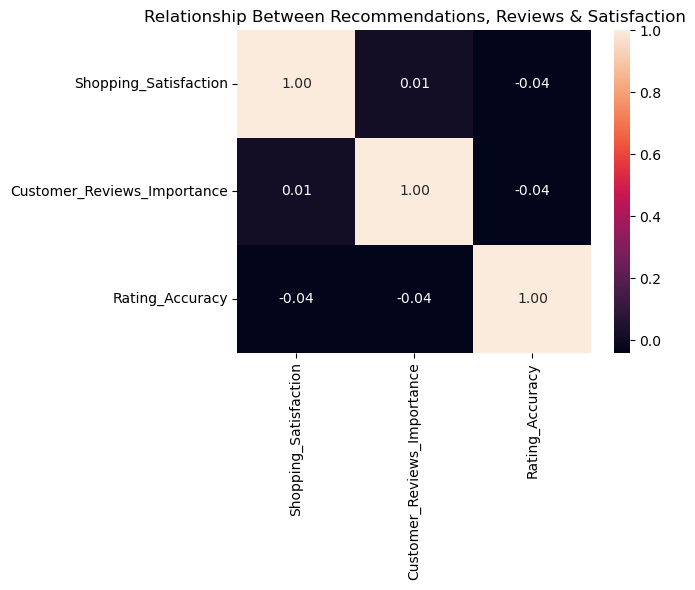

In [147]:
# Heatmap:

plt.figure(figsize=(7,6))
sns.heatmap(correlation,annot=True,fmt=".2f") 
plt.title("Relationship Between Recommendations, Reviews & Satisfaction") 
plt.tight_layout() 
plt.show()

In [74]:
# 4.2: Impact of Review Reliability & Helpfulness on Ratings

df["Review_Reliability"].value_counts()


Review_Reliability
Rarely          185
Never           164
Moderately      159
Heavily         150
Occasionally    142
Name: count, dtype: int64

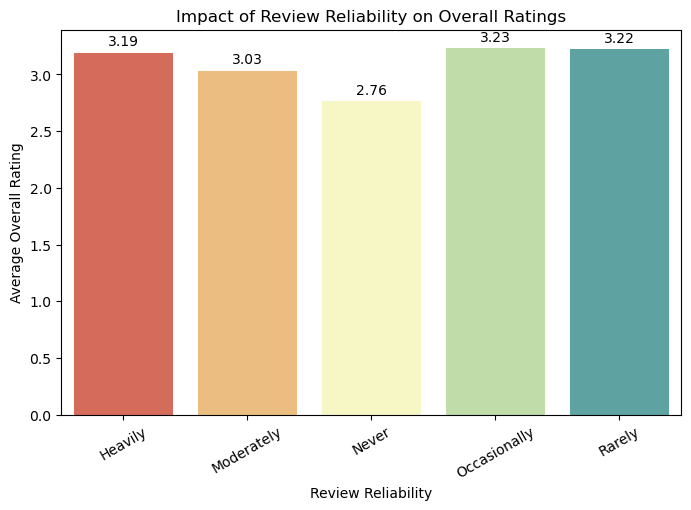

In [131]:
avg_rating = (
    df.groupby("Review_Reliability")["Rating_Accuracy"]
    .mean())
    
plt.figure(figsize=(8,5))
ax = sns.barplot(
    x=avg_rating.index,
    y=avg_rating.values,
    palette="Spectral")

# 🔹 Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)
    
plt.xlabel("Review Reliability")
plt.ylabel("Average Overall Rating")
plt.title("Impact of Review Reliability on Overall Ratings")
plt.xticks(rotation=30)
plt.show()

# Insight: Low engagement (never) correlates with low satisfaction, while light engagement (occasional/rare) correlates with slightly higher ratings.

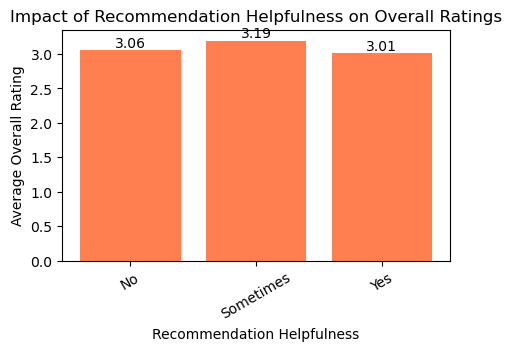

In [137]:
avg_rating_help = (
    df.groupby("Recommendation_Helpfulness")["Rating_Accuracy"]
    .mean())

plt.figure(figsize=(5,3))
bars = plt.bar(
    avg_rating_help.index,
    avg_rating_help.values,
    color="coral")

plt.xlabel("Recommendation Helpfulness")
plt.ylabel("Average Overall Rating")
plt.title("Impact of Recommendation Helpfulness on Overall Ratings")
plt.xticks(rotation=30)

# Data labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom")

plt.show()


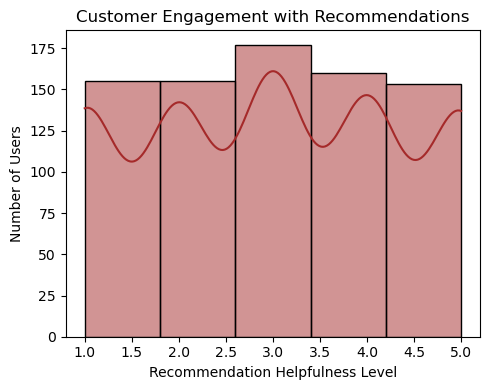

In [123]:
# 4.3: Identify trends in how often customers engage with or trust personalized recommendations

plt.figure(figsize=(5,4)) 

sns.histplot(df['Customer_Reviews_Importance'],bins=5,kde=True,color='brown') 
plt.title("Customer Engagement with Recommendations") 
plt.xlabel("Recommendation Helpfulness Level") 
plt.ylabel("Number of Users") 
plt.tight_layout() 
plt.show()

In [98]:
# 4.4: Suggest actionable insights for improving eBay’s recommendation system.

### Recommendation:
-  Recommendation helpfulness has a weak correlation with satisfaction.
-  Rating behavior varies with user engagement. Low engagement (never) correlates with low satisfaction, while light engagement (occasional/rare) correlates with slightly higher ratings.
-  Review reliability alone does not strongly impact ratings.
-  Personalize recommendations – Tailor recommendations for users with lower engagement (ratings 1–2) to increase interaction.

## Task 5: Visualization and Reporting

* Create attractive visualizations (bar charts, heatmaps, pie charts) for:
  - Purchase categories
  - Browsing frequency distribution
  - Satisfaction levels
  - Correlation between recommendation usefulness and satisfaction
* Summarize findings in a clear and visually appealing report format. ion

In [112]:
# 5.1: Create attractive visualizations (bar charts, heatmaps, pie charts) for: 

## a:) Purchase categories
df['Purchase_Categories'].value_counts()
df['Category_List'] = df['Purchase_Categories'].str.split(';')

In [106]:
categories_dummies = df['Category_List'].str.join('|').str.get_dummies()

In [109]:
print(categories_dummies)

     Beauty and Personal Care  Clothing and Fashion  \
0                           0                     0   
1                           1                     1   
2                           1                     1   
3                           1                     0   
4                           0                     1   
..                        ...                   ...   
795                         1                     1   
796                         0                     0   
797                         0                     1   
798                         1                     1   
799                         0                     0   

     Groceries and Gourmet Food  Home and Kitchen  others  
0                             1                 1       0  
1                             1                 0       1  
2                             1                 0       0  
3                             1                 0       0  
4                             1        

In [111]:
# Sum each category column to get total count of customers buying it
category_counts = categories_dummies.sum().sort_values(ascending=False)
category_counts

Clothing and Fashion          450
Home and Kitchen              421
Beauty and Personal Care      418
others                        390
Groceries and Gourmet Food    366
dtype: int64

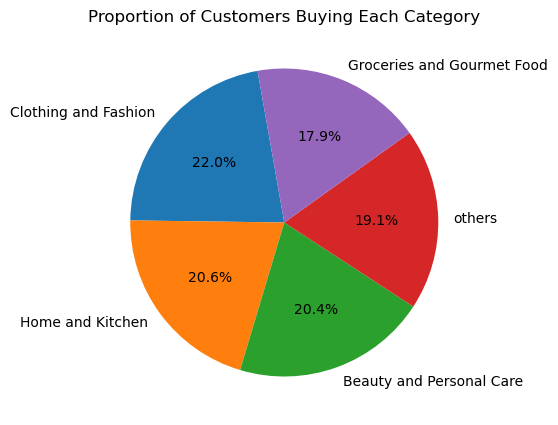

In [140]:
plt.figure(figsize=(5,5))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=100)
plt.title('Proportion of Customers Buying Each Category')
plt.show()

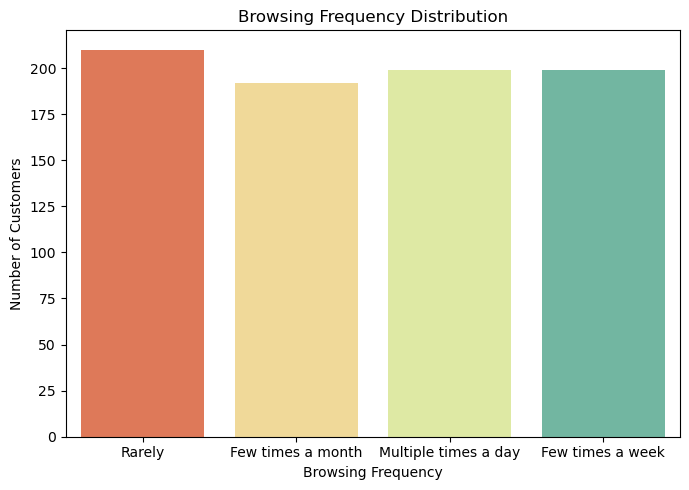

In [142]:
# b) Browsing frequency distribution 

plt.figure(figsize=(7,5)) 
sns.countplot(x=df['Browsing_Frequency'], palette="Spectral") 
plt.title("Browsing Frequency Distribution") 
plt.xlabel("Browsing Frequency") 
plt.ylabel("Number of Customers") 
plt.tight_layout() 
plt.show()

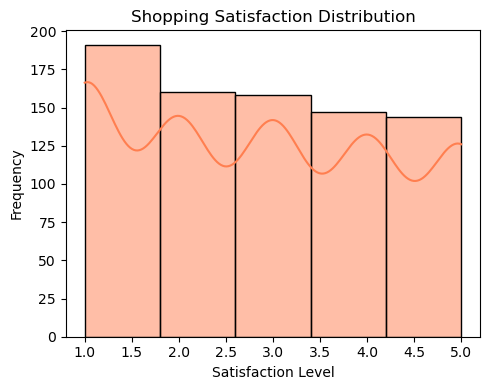

In [124]:
# c) Satisfaction Levels

plt.figure(figsize=(5,4)) 

sns.histplot(df['Shopping_Satisfaction'], bins=5, kde=True, color ="coral") 
plt.title("Shopping Satisfaction Distribution") 
plt.xlabel("Satisfaction Level") 
plt.ylabel("Frequency") 
plt.tight_layout() 
plt.show()

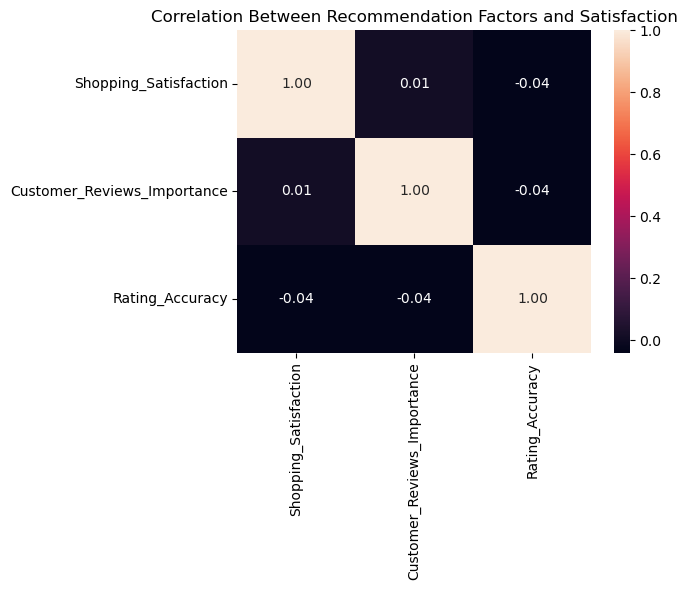

In [143]:
# d) Correlation: Recommendation Usefulness vs Satisfaction.

correlation=df[['Shopping_Satisfaction', 'Customer_Reviews_Importance', 'Rating_Accuracy']].corr()

plt.figure(figsize=(7,6))
sns.heatmap(correlation,annot=True,fmt=".2f") 
plt.title("Correlation Between Recommendation Factors and Satisfaction") 
plt.tight_layout() 
plt.show()

### 5.2: Summarize findings in a clear and visually appealing report format. 
- Category Focus: Most purchases come from a few categories (Clothing and Fashion, Home & Kitchen, Beauty)—target these for better recommendations.

- Browsing Stage: Frequent browsing highlights the importance of timely, personalized suggestions.

- Engagement Matters: Customers interact more when recommendations are relevant.

- Satisfaction Levels: Shopping satisfaction is moderately high for most customers. Helpful recommendations boost shopping satisfaction and loyalty.

- Recommendation Usefulness vs Satisfaction: A positive correlation exists between recommendation usefulness and shopping satisfaction. Customers who find recommendations helpful tend to report higher satisfaction levels.


## Video Link:
* Part 1- https://www.loom.com/share/60c1c93da84943a2aeee0b7a9d0be54c
* Part 2- https://www.loom.com/share/b3349d74b2d44eecaa3deb97142b4aa3